# Fluxo de Kovasznay Inverso
---

In [31]:
import os
os.environ['DDE_BACKEND'] = 'pytorch'
import deepxde as dde
import numpy as np
import pandas as pd
import re
from matplotlib import pyplot as plt

In [32]:
# https://deepxde.readthedocs.io/en/latest/modules/deepxde.optimizers.html#module-deepxde.optimizers.config
dde.config.set_default_float("float64")

# Para reprodução dos experimentos
np.random.seed(42)
dde.config.set_random_seed(42)

Set the default float type to float64


## Problema inverso

Por se tratar de um problema inverso, em que queremos descobrir o número de Reynolds que gerou os dados disponíveis, definimos um chute inicial e atribuímos a uma variável que terá seu valor modificado ao longo do treinamento da rede.

In [33]:
Re = 50

Re_guess = 10.0

ex_Re = dde.Variable(Re_guess)

## Residual

Definimos as equações de Navier-Stokes como um residual a ser minimizado.

In [34]:
def pde(x, y):
    
    u, v, p = y[:, 0:1], y[:, 1:2], y[:, 2:]
    
    du_dx = dde.grad.jacobian(y, x, i=0, j=0)
    du_dy = dde.grad.jacobian(y, x, i=0, j=1)
    
    dv_dx = dde.grad.jacobian(y, x, i=1, j=0)
    dv_dy = dde.grad.jacobian(y, x, i=1, j=1)
    
    du_dxx = dde.grad.hessian(y, x, i=0, j=0, component=0)
    du_dyy = dde.grad.hessian(y, x, i=1, j=1, component=0)
    
    dv_dxx = dde.grad.hessian(y, x, i=0, j=0, component=1)
    dv_dyy = dde.grad.hessian(y, x, i=1, j=1, component=1)

    dp_dx = dde.grad.jacobian(y, x, i=2, j=0)
    dp_dy = dde.grad.jacobian(y, x, i=2, j=1)

    momentum_x = (
        u * du_dx + v * du_dy + dp_dx - 1 / ex_Re * (du_dxx + du_dyy)
    )
    
    momentum_y = (
        u * dv_dx + v * dv_dy + dp_dy - 1 / ex_Re * (dv_dxx + dv_dyy)
    )
    
    continuity = du_dx + dv_dy

    return [momentum_x, momentum_y, continuity]

## Solução Exata

Sendo:
$$
\lambda = \frac{1}{2v} - \sqrt{\frac{1}{4v^{2}} + 4\pi^{2}}
$$

As soluções para os campos são dadas por:
$$
u = 1 - e^{\lambda x} cos(2\pi y), \quad 
v = \frac{\lambda}{2\pi}e^{\lambda x}sin(2\pi y), \quad
p = \frac{1}{2}(1 - e^{2\lambda x})
$$

In [35]:
nu = 1 / Re
l = 1 / (2 * nu) - np.sqrt(1 / (4 * nu ** 2) + 4 * np.pi ** 2)

In [36]:
def u_sol(x):
    return 1 - np.exp(l * x[:, 0:1]) * np.cos(2 * np.pi * x[:, 1:2])

def v_sol(x):
    return l / (2 * np.pi) * np.exp(l * x[:, 0:1]) * np.sin(2 * np.pi * x[:, 1:2])

def p_sol(x):
    return 1 / 2 * (1 - np.exp(2 * l * x[:, 0:1]))

## Pertubação nos Dados

Adicionamos ruído gaussiano aos dados para testar a resiliência do método.

In [37]:
noise_percentage = 0.1

In [38]:
def get_noise(x):
    return noise_percentage * np.std(x) * np.random.normal(size=x.shape)

def noisy_u_sol(x):
    u = u_sol(x)
    return u + get_noise(u) 

def noisy_v_sol(x):
    v = v_sol(x)
    return v + get_noise(v)

def noisy_p_sol(x):
    p = p_sol(x)
    return p + get_noise(p)

## Condições de fronteira e dados

O problema será resolvido dentro de um retângulo: 
$$
-0.5 \leq x \leq 1, \qquad -0.5 \leq y \leq 1.5  
$$


In [39]:
x0, xf = -0.5, 1
y0, yf = -0.5, 1.5

In [40]:
def boundary_outflow(x, on_boundary):
    return on_boundary and dde.utils.isclose(x[0], xf)

spatial_domain = dde.geometry.Rectangle(xmin=[x0, y0], xmax=[xf, yf])

u_bc = dde.icbc.DirichletBC(
    spatial_domain, u_sol, lambda _, on_boundary: on_boundary, component=0
)

v_bc = dde.icbc.DirichletBC(
    spatial_domain, v_sol, lambda _, on_boundary: on_boundary, component=1
)

right_p_bc = dde.icbc.DirichletBC(
    spatial_domain, p_sol, boundary_outflow, component=2
)

data_cp = spatial_domain.random_points(1000)

noisy_data_u = noisy_u_sol(data_cp)
noisy_data_v = noisy_v_sol(data_cp)
noisy_data_p = noisy_p_sol(data_cp)

noisy_data_u_bc = dde.icbc.PointSetBC(data_cp, noisy_data_u, component=0)
noisy_data_v_bc = dde.icbc.PointSetBC(data_cp, noisy_data_v, component=1)
noisy_data_p_bc = dde.icbc.PointSetBC(data_cp, noisy_data_p, component=2)

## Pontos de colocação

In [41]:
num_domain = 2048
num_boundary = 400
num_test = 512

In [42]:
noisy_data = dde.data.PDE(
    spatial_domain,
    pde,
    [
        u_bc, v_bc, right_p_bc,
        noisy_data_u_bc, noisy_data_v_bc, noisy_data_p_bc
    ],
    num_domain=num_domain,
    num_boundary=num_boundary,
    num_test=num_test,
    anchors=data_cp
)

## Definindo as configurações da rede

In [43]:
n_hidden_layers = 4
nodes_per_layer = 50
topology = [2] + n_hidden_layers * [nodes_per_layer] + [3]
activation = "tanh"
initialization = "Glorot normal"

net = dde.nn.FNN(topology, activation, initialization)

noisy_model = dde.Model(noisy_data, net)

## Treinando o modelo

In [44]:
adam_iterations = 60000

ex_variable_cb = dde.callbacks.VariableValue(
    [ex_Re], 
    period=1000, 
    filename=f"../parametros/Re{Re}.dat"
)

noisy_model.compile("adam", lr=1e-3, external_trainable_variables=[ex_Re])

Compiling model...
'compile' took 2.824467 s



In [45]:
losshistory, train_state = noisy_model.train(
    iterations=adam_iterations, 
    display_every=5000,
    callbacks=[ex_variable_cb])

Training model...

Step      Train loss                                                                                    Test loss                                                                                     Test metric
0         [1.05e-02, 1.63e-01, 2.13e-01, 2.80e+00, 1.24e-01, 1.62e-01, 1.77e+00, 9.62e-02, 1.69e-01]    [1.01e-02, 1.71e-01, 2.21e-01, 2.80e+00, 1.24e-01, 1.62e-01, 1.77e+00, 9.62e-02, 1.69e-01]    []  
5000      [9.50e-03, 9.58e-04, 1.20e-03, 1.37e-02, 1.78e-03, 8.09e-04, 4.57e-02, 2.45e-03, 9.01e-03]    [1.04e-02, 5.61e-04, 1.02e-03, 1.37e-02, 1.78e-03, 8.09e-04, 4.57e-02, 2.45e-03, 9.01e-03]    []  
10000     [1.31e-02, 9.40e-04, 1.34e-03, 7.83e-03, 5.55e-04, 6.33e-04, 2.67e-02, 1.03e-03, 6.53e-03]    [1.43e-02, 5.98e-04, 1.22e-03, 7.83e-03, 5.55e-04, 6.33e-04, 2.67e-02, 1.03e-03, 6.53e-03]    []  
15000     [3.97e-03, 3.55e-04, 5.01e-04, 4.11e-03, 4.17e-04, 3.96e-04, 1.58e-02, 5.77e-04, 4.35e-03]    [4.69e-03, 2.52e-04, 5.16e-04, 4.11e-03, 4.17e-04, 3.96e-0

## Salvando o modelo

In [46]:
dde.saveplot(
    losshistory, 
    train_state, 
    issave=True, 
    isplot=False, 
    output_dir="../perdas", 
    loss_fname=f"Re{Re}-loss",
    train_fname=f"Re{Re}-train",
    test_fname=f"Re{Re}-test")

noisy_model.save(f"../modelos/Re{Re}")

Saving loss history to ../perdas/Re50-loss ...
Saving training data to ../perdas/Re50-train ...
Saving test data to ../perdas/Re50-test ...


'../modelos/Re50-60000.pt'

## Visualizando resultados

In [47]:

def plot_and_save_losses(losshistory, fig_name):
    
    X = losshistory.steps
    train = np.sum(losshistory.loss_train, axis=1)
    test = np.sum(losshistory.loss_test, axis=1)
    
    plt.semilogy(X, train, "o-", label="Treinamento", linewidth=2)
    plt.semilogy(X, test, "x-", label="Teste", linewidth=2)
    
    plt.xlabel("Iteração")
    plt.ylabel("Erro em escala logarítmica")
    
    plt.legend()
    plt.grid()
    plt.savefig(f"../figuras/{fig_name}.png")
    plt.show()


def plot_parameter_approximation(path, real_value, fig_name):
    
    def parse_line(line):
        match = re.match(r'(\S+)\s*\[(\S+)\]', line.strip())
        if match:
            return [float(x) for x in match.groups()]
        return None 
    
    with open(path, 'r') as f:
        parsed_data = [parse_line(line) for line in f if not line.startswith('#') and line.strip()]
        parsed_data = [x for x in parsed_data if x is not None]

    df = pd.DataFrame(parsed_data, columns=['x', 'y'])
    
    iterations = df['x'].values
    reynolds = df['y'].values
    
    plt.plot(iterations, reynolds, color="blue", linewidth=2, linestyle='--', marker="o", markersize=5, label=r"$Re$ estimado")
    plt.axhline(y=real_value, color='r', label=r"$Re$ real")
    
    plt.xlabel("iteração")
    plt.ylabel(r"$Re$")

    plt.grid()
    plt.legend()
    plt.savefig(f"../figuras/{fig_name}.png")
    plt.show()

def plot_3d_projection(surface, title):
    fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
    ax.plot_surface(Y, X, surface, vmin=surface.min() * 2, cmap="viridis")
    plt.xlabel("y")
    plt.ylabel("x")
    plt.title(title)
    plt.savefig(f"../figuras/{title}-{Re}.png")
    plt.show()

### Valor estimado

In [50]:
ex_Re.detach().cpu().numpy()

array(50.15600202)

### Gráficos

In [54]:
noisy_model.restore(f"../modelos/Re{Re}-{adam_iterations}.pt")

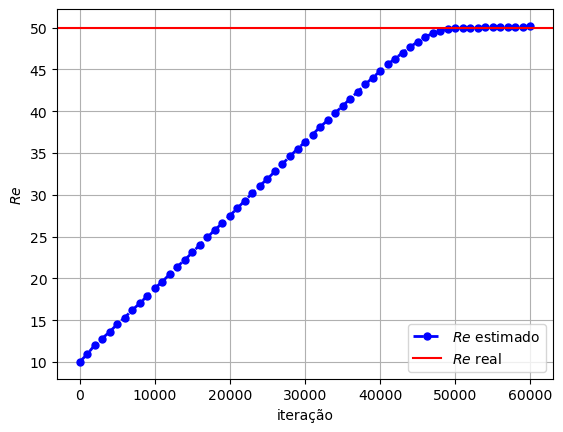

In [56]:
plot_parameter_approximation(f"../parametros/Re{Re}.dat", Re, f"Re{Re}-valores-re")

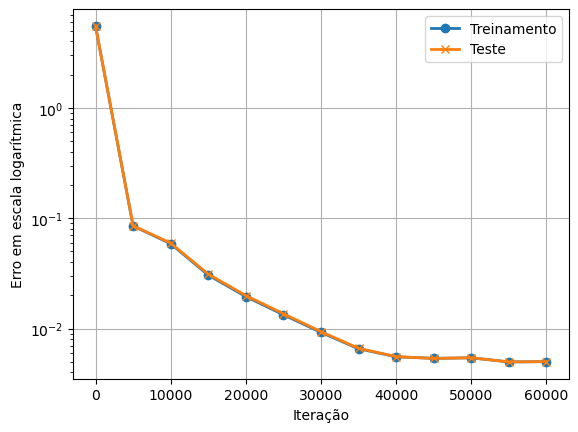

In [57]:
plot_and_save_losses(losshistory, f"Re{Re}-loss")

## Comparando resultados

### Visualizando superfícies

In [ ]:
#noisy_model.restore(f"./models/Re{Re}-noisy-{adam_iterations + lbfgs_iterations}.pdparams")

In [58]:
nop = 100

X = np.linspace(-0.5, 1, nop)
Y = np.linspace(-0.5, 1.5, nop)

X, Y = np.meshgrid(X, Y)
XY = np.vstack((X.flatten(), Y.flatten())).T

In [59]:
predicted_values = noisy_model.predict(XY)

u_predicted = predicted_values[:,0].reshape((nop, nop))
v_predicted = predicted_values[:,1].reshape((nop, nop))
p_predicted = predicted_values[:,2].reshape((nop, nop))

In [60]:
u_real = u_sol(XY).reshape((nop, nop))
u_noisy = noisy_u_sol(XY).reshape((nop, nop))

v_real = v_sol(XY).reshape((nop, nop))
v_noisy = noisy_v_sol(XY).reshape((nop, nop))

p_real = p_sol(XY).reshape((nop, nop))
p_noisy = noisy_p_sol(XY).reshape((nop, nop))

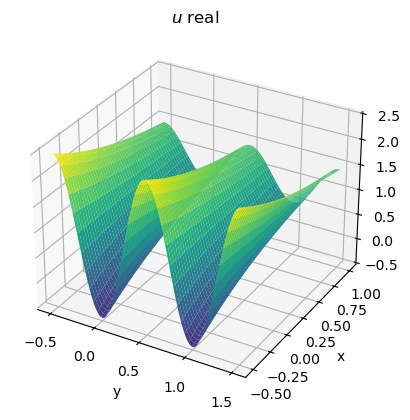

In [61]:
plot_3d_projection(u_real, r"$u$ real")

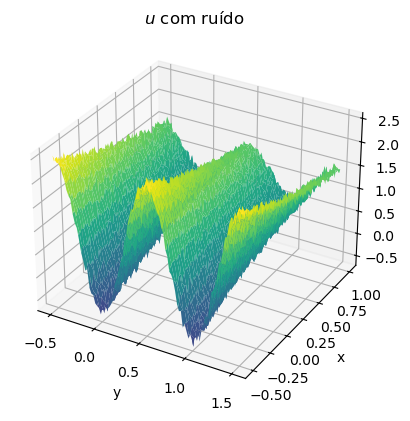

In [62]:
plot_3d_projection(u_noisy, r"$u$ com ruído")

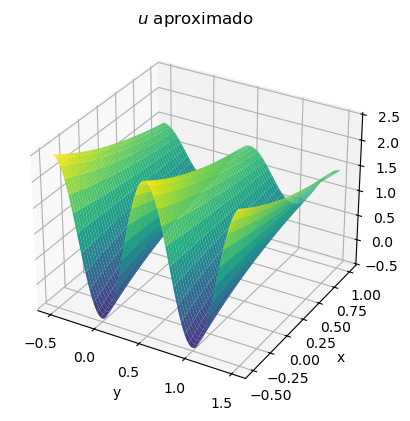

In [63]:
plot_3d_projection(u_predicted, r"$u$ aproximado")

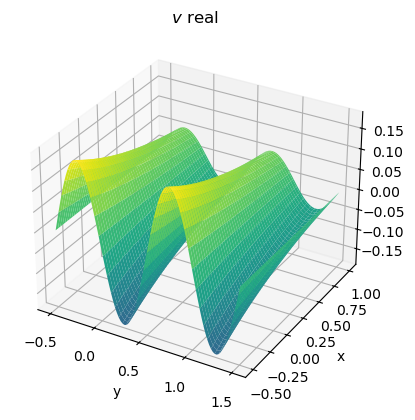

In [64]:
plot_3d_projection(v_real, r"$v$ real")

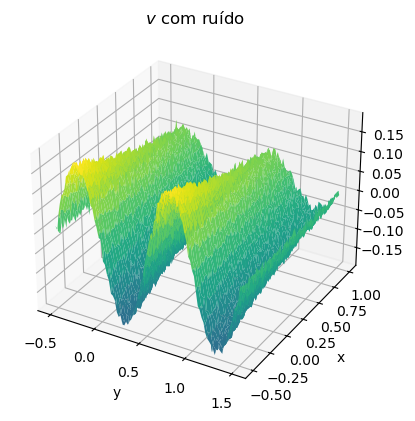

In [65]:
plot_3d_projection(v_noisy, r"$v$ com ruído")

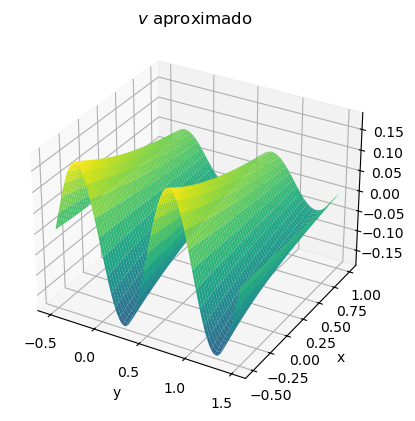

In [66]:
plot_3d_projection(v_predicted, r"$v$ aproximado")

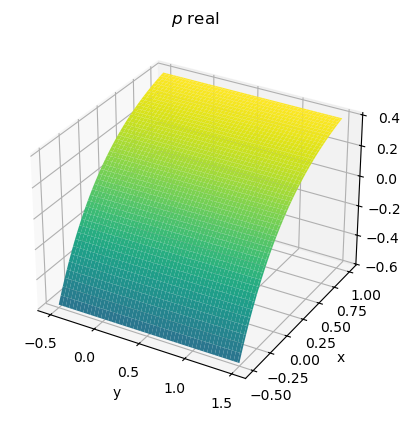

In [67]:
plot_3d_projection(p_real, r"$p$ real")

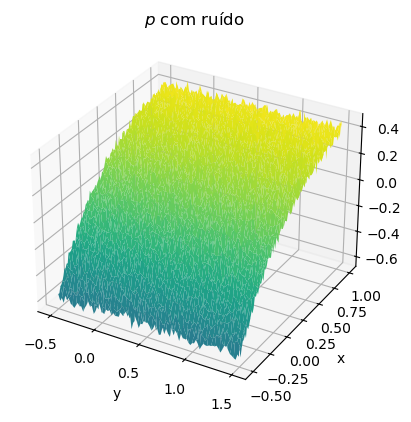

In [68]:
plot_3d_projection(p_noisy, r"$p$ com ruído")

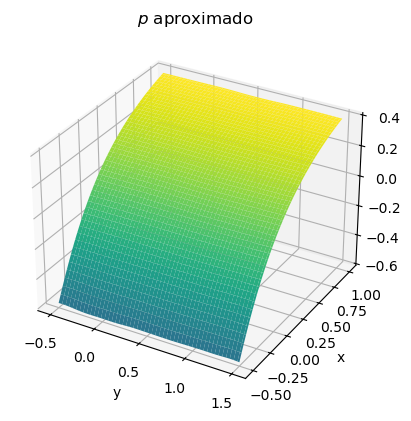

In [69]:
plot_3d_projection(p_predicted, r"$p$ aproximado")

## Métricas

### RMSE

In [85]:
np.sqrt(dde.metrics.mean_squared_error(u_real, u_predicted))

np.float64(0.006423317381028045)

In [86]:
np.sqrt(dde.metrics.mean_squared_error(v_real, v_predicted))

np.float64(0.0012272437659662774)

In [88]:
np.sqrt(dde.metrics.mean_squared_error(p_real, p_predicted))

np.float64(0.002545093153832217)

### MAPE

In [73]:
dde.metrics.mean_absolute_percentage_error(u_real, u_predicted)

np.float64(6.286528435326418)

In [74]:
dde.metrics.mean_absolute_percentage_error(v_real, v_predicted)

np.float64(11134474319057.402)

In [75]:
dde.metrics.mean_absolute_percentage_error(p_real, p_predicted)

np.float64(13458098384811.86)

### Acurácia

In [76]:
dde.metrics.accuracy(u_real, u_predicted)

np.float64(0.99)

In [77]:
dde.metrics.accuracy(v_real, v_predicted)

np.float64(0.97)

In [78]:
dde.metrics.accuracy(p_real, p_predicted)

np.float64(1.0)

### L2

In [79]:
dde.metrics.l2_relative_error(u_real, u_predicted)

np.float64(0.005344185191483733)

In [80]:
dde.metrics.l2_relative_error(v_real, v_predicted)

np.float64(0.01532688688179799)

In [81]:
dde.metrics.l2_relative_error(p_real, p_predicted)

np.float64(0.008892910095819719)

### L-Infinity

In [82]:
np.max(np.abs(u_real - u_predicted))

np.float64(0.01702583620889353)

In [83]:
np.max(np.abs(v_real - v_predicted))

np.float64(0.005258960670409289)

In [84]:
np.max(np.abs(p_real - p_predicted))

np.float64(0.009205684335511721)